In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

TensorFlow: 2.21.0
Keras: 3.15.1


In [2]:
# Load the MNIST handwritten digits dataset
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

print("Training images:", x_train.shape)
print("Test images:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training images: (60000, 28, 28)
Test images: (10000, 28, 28)


In [3]:
# Convert pixel values from 0–255 to 0–1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [4]:
# Build the encoder
encoder = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu")
])

encoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ Layer (type)           ┃ Output Shape    ┃   Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ flatten (Flatten)      │ (None, 784)     │         0 │
├────────────────────────┼─────────────────┼───────────┤
│ dense (Dense)          │ (None, 128)     │   100,480 │
├────────────────────────┼─────────────────┼───────────┤
│ dense_1 (Dense)        │ (None, 64)      │     8,256 │
└────────────────────────┴─────────────────┴───────────┘

 Total params: 108,736 (424.75 KB)

 Trainable params: 108,736 (424.75 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Build the decoder
decoder = keras.Sequential([
    layers.Input(shape=(64,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(28 * 28, activation="sigmoid"),
    layers.Reshape((28, 28))
])

decoder.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ Layer (type)           ┃ Output Shape    ┃   Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ dense_2 (Dense)        │ (None, 128)     │     8,320 │
├────────────────────────┼─────────────────┼───────────┤
│ dense_3 (Dense)        │ (None, 784)     │   101,136 │
├────────────────────────┼─────────────────┼───────────┤
│ reshape (Reshape)      │ (None, 28, 28)  │         0 │
└────────────────────────┴─────────────────┴───────────┘

 Total params: 109,456 (427.56 KB)

 Trainable params: 109,456 (427.56 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Connect the encoder and decoder
autoencoder = keras.Sequential([
    encoder,
    decoder
])

autoencoder.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ Layer (type)           ┃ Output Shape    ┃   Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ sequential             │ (None, 64)      │   108,736 │
│ (Sequential)           │                 │           │
├────────────────────────┼─────────────────┼───────────┤
│ sequential_1           │ (None, 28, 28)  │   109,456 │
│ (Sequential)           │                 │           │
└────────────────────────┴─────────────────┴───────────┘

 Total params: 218,192 (852.31 KB)

 Trainable params: 218,192 (852.31 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Train the autoencoder
history = autoencoder.fit(
    x_train,
    x_train,
    epochs=10,
    batch_size=256,
    validation_data=(x_test, x_test)
)

ValueError: You must call `compile()` before using the model.

In [8]:
x_train,
x_train


array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [9]:
autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

print("Autoencoder is ready for training!")

Autoencoder is ready for training!


In [10]:
history = autoencoder.fit(
    x_train,
    x_train,
    epochs=10,
    batch_size=256,
    validation_data=(x_test, x_test)
)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.2256 - val_loss: 0.1432
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.1264 - val_loss: 0.1130
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.1082 - val_loss: 0.1017
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.1000 - val_loss: 0.0961
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.0950 - val_loss: 0.0921
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0920 - val_loss: 0.0897
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.0899 - val_loss: 0.0881
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.0881 - val_loss: 0.0864
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0867 - val_loss: 0.0850
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.0855 - val_loss: 0.0840


In [1]:
import matplotlib.pyplot as plt

# Take one image the model has never seen during training
original = x_test[0]

# Reconstruct it
reconstructed = autoencoder.predict(
    original.reshape(1, 28, 28),
    verbose=0
)[0]

# Display both images
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(original, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(reconstructed, cmap="gray")
plt.title("Reconstructed")
plt.axis("off")

# Save the image as a PNG file
plt.savefig("original_vs_reconstructed_7.png", bbox_inches="tight")

plt.show()

NameError: name 'x_test' is not defined

In [12]:
import matplotlib.pyplot as plt

# Take one image the model has never seen during training
original = x_test[0]

# Ask the autoencoder to reconstruct it
reconstructed = autoencoder.predict(
    original.reshape(1, 28, 28),
    verbose=0
)[0]

# Display original and reconstructed images
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(original, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(reconstructed, cmap="gray")
plt.title("Reconstructed")
plt.axis("off")

plt.show()

ModuleNotFoundError: No module named 'matplotlib'

In [13]:
autoencoder.save("my_autoencoder.keras")

In [14]:
autoencoder.save("my_autoencoder.keras")

In [15]:
autoencoder.save("my_autoencoder.keras")

In [16]:
autoencoder.save("my_autoencoder.keras")

In [17]:
import os
print(os.path.exists("my_autoencoder.keras"))

True


In [1]:
import tensorflow as tf
from tensorflow import keras

# Load MNIST again
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

# Normalize pixel values
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("MNIST loaded successfully!")
print("Test images:", x_test.shape)

MNIST loaded successfully!
Test images: (10000, 28, 28)


In [2]:
autoencoder = keras.models.load_model("my_autoencoder.keras")

print("Autoencoder loaded successfully!")

Autoencoder loaded successfully!


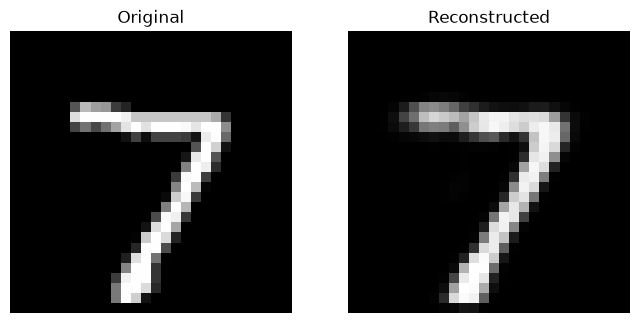

In [3]:
import matplotlib.pyplot as plt

# Take one test image
original = x_test[0]

# Let the autoencoder reconstruct it
reconstructed = autoencoder.predict(
    original.reshape(1, 28, 28),
    verbose=0
)[0]

# Display both images
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(original, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(reconstructed, cmap="gray")
plt.title("Reconstructed")
plt.axis("off")

plt.show()

In [2]:
import os

print(os.path.exists("original_vs_reconstructed_7.png"))

False


In [3]:
import matplotlib.pyplot as plt
import os

original = x_test[0]

reconstructed = autoencoder.predict(
    original.reshape(1, 28, 28),
    verbose=0
)[0]

# Create the comparison image
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(original, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(reconstructed, cmap="gray")
plt.title("Reconstructed")
plt.axis("off")

# Save explicitly in the current project folder
file_path = os.path.join(os.getcwd(), "original_vs_reconstructed_7.png")
plt.savefig(file_path, bbox_inches="tight")
plt.show()

print("Saved to:")
print(file_path)
print("File exists:", os.path.exists(file_path))

NameError: name 'x_test' is not defined